In [30]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/netflix_titles.csv')

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [31]:
df.shape

(8807, 12)

Week-2

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [33]:
print("Null values in each column:")
df.isnull().sum()

duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

print("--- Unique Ratings ---")
print(df['rating'].unique())

print("\n--- Unique Types ---")
print(df['type'].unique())

Null values in each column:
Total duplicate rows: 0
--- Unique Ratings ---
['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' '74 min' '84 min' '66 min' 'NR' nan 'TV-Y7-FV' 'UR']

--- Unique Types ---
['Movie' 'TV Show']


In [34]:
inconsistent_mask = df['rating'].astype(str).str.contains('min|Season', na=False)
df.loc[inconsistent_mask, 'duration'] = df.loc[inconsistent_mask, 'rating']
df.loc[inconsistent_mask, 'rating'] = 'Unknown'

print("Duplicates and inconsistent categories handled.")

Duplicates and inconsistent categories handled.


In [35]:
#  Unknown
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

#  Mode
most_common_country = df['country'].mode()[0]
df['country'] = df['country'].fillna(most_common_country)

most_common_rating = df['rating'].mode()[0]
df['rating'] = df['rating'].fillna(most_common_rating)

df = df.dropna(subset=['date_added', 'duration'])

# Final check
print("Null values remaining after targeted cleaning:")
print(df.isnull().sum())

Null values remaining after targeted cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


Week-3

In [36]:
categorical_columns = ['type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in']
for col in categorical_columns:
    df[col] = df[col].astype(str).str.strip().str.title()

columns_with_lists = ['director', 'cast', 'country', 'listed_in']
for col in columns_with_lists:
    df[col] = df[col].str.replace(r'\s*,\s*', ', ', regex=True)

df['genres'] = df['listed_in'].apply(lambda x: [i.strip() for i in x.split(',')])

rating_map = {
    'Tv-Y': 'Kids',   'Tv-Y7': 'Kids',    'G': 'Kids',
    'Tv-G': 'General','Pg': 'General',    'Tv-Pg': 'General',
    'Pg-13': 'Teen',  'Tv-14': 'Teen',
    'R': 'Mature',    'Tv-Ma': 'Mature',  'Nc-17': 'Mature',
    'Nr': 'Unrated',  'Ur': 'Unrated',
}
df['rating_category'] = df['rating'].map(rating_map).fillna('Other')


df['countries_list'] = df['country'].apply(
    lambda x: [c.strip() for c in x.split(',')] if x not in ['Unknown', 'Nan'] else ['Unknown']
)
df['primary_country'] = df['countries_list'].apply(lambda x: x[0])

print("Categorical data normalization and feature engineering completed!")
print(df['rating_category'].value_counts())

Categorical data normalization and feature engineering completed!
rating_category
Mature     4011
Teen       2647
General    1368
Kids        680
Unrated      82
Other         9
Name: count, dtype: int64


In [37]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genres,rating_category,countries_list,primary_country
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,Pg-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",[Documentaries],Teen,[United States],United States
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,Tv-Ma,2 Seasons,"International Tv Shows, Tv Dramas, Tv Mysteries","After crossing paths at a party, a Cape Town t...","[International Tv Shows, Tv Dramas, Tv Mysteries]",Mature,[South Africa],South Africa
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,Tv-Ma,1 Season,"Crime Tv Shows, International Tv Shows, Tv Act...",To protect his family from a powerful drug lor...,"[Crime Tv Shows, International Tv Shows, Tv Ac...",Mature,[United States],United States
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Unknown,United States,"September 24, 2021",2021,Tv-Ma,1 Season,"Docuseries, Reality Tv","Feuds, flirtations and toilet talk go down amo...","[Docuseries, Reality Tv]",Mature,[United States],United States
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,Tv-Ma,2 Seasons,"International Tv Shows, Romantic Tv Shows, Tv ...",In a city of coaching centers known to train I...,"[International Tv Shows, Romantic Tv Shows, Tv...",Mature,[India],India
5,s6,Tv Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,"September 24, 2021",2021,Tv-Ma,1 Season,"Tv Dramas, Tv Horror, Tv Mysteries",The arrival of a charismatic young priest brin...,"[Tv Dramas, Tv Horror, Tv Mysteries]",Mature,[United States],United States
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,"September 24, 2021",2021,Pg,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,[Children & Family Movies],General,[United States],United States
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,Tv-Ma,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...","[Dramas, Independent Movies, International Mov...",Mature,"[United States, Ghana, Burkina Faso, United Ki...",United States
8,s9,Tv Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,Tv-14,9 Seasons,"British Tv Shows, Reality Tv",A talented batch of amateur bakers face off in...,"[British Tv Shows, Reality Tv]",Teen,[United Kingdom],United Kingdom
9,s10,Movie,The Starling,Theodore Melfi,"Melissa Mccarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,Pg-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,"[Comedies, Dramas]",Teen,[United States],United States


In [38]:
duplicate_count = df.drop(columns=['genres', 'countries_list']).duplicated().sum()
print(duplicate_count)

0


In [39]:
# date

df['date_added'] = pd.to_datetime(df['date_added'].astype(str).str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name() # Gets the actual name like 'September'

df['release_year'] = pd.to_datetime(df['release_year'].astype(str), format='%Y')

# check
print("--- Data Types After Conversion ---")
print(df[['date_added', 'year_added', 'month_added']].dtypes)

print("\n--- Quick Preview of the Dates ---")
print(df[['date_added', 'year_added', 'month_added']].head())



--- Data Types After Conversion ---
date_added     datetime64[ns]
year_added              int32
month_added            object
dtype: object

--- Quick Preview of the Dates ---
  date_added  year_added month_added
0 2021-09-25        2021   September
1 2021-09-24        2021   September
2 2021-09-24        2021   September
3 2021-09-24        2021   September
4 2021-09-24        2021   September


In [40]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genres,rating_category,countries_list,primary_country,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020-01-01,Pg-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",[Documentaries],Teen,[United States],United States,2021,September
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021-01-01,Tv-Ma,2 Seasons,"International Tv Shows, Tv Dramas, Tv Mysteries","After crossing paths at a party, a Cape Town t...","[International Tv Shows, Tv Dramas, Tv Mysteries]",Mature,[South Africa],South Africa,2021,September
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021-01-01,Tv-Ma,1 Season,"Crime Tv Shows, International Tv Shows, Tv Act...",To protect his family from a powerful drug lor...,"[Crime Tv Shows, International Tv Shows, Tv Ac...",Mature,[United States],United States,2021,September
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021-09-24,2021-01-01,Tv-Ma,1 Season,"Docuseries, Reality Tv","Feuds, flirtations and toilet talk go down amo...","[Docuseries, Reality Tv]",Mature,[United States],United States,2021,September
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021-01-01,Tv-Ma,2 Seasons,"International Tv Shows, Romantic Tv Shows, Tv ...",In a city of coaching centers known to train I...,"[International Tv Shows, Romantic Tv Shows, Tv...",Mature,[India],India,2021,September


Week-4

In [41]:
# Handle duration column
df[['duration_val', 'duration_unit']] = df['duration'].str.split(' ', n=1, expand=True)
df['duration_val'] = df['duration_val'].astype(float)
df['movie_mins'] = df.apply(lambda x: x['duration_val'] if 'min' in str(x['duration_unit']) else None, axis=1)
df['tv_seasons'] = df.apply(lambda x: x['duration_val'] if 'Season' in str(x['duration_unit']) else None, axis=1)

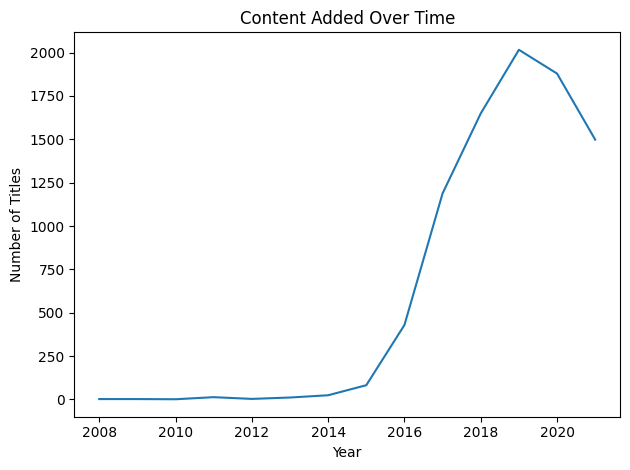

In [42]:
# Content Growth Over Time
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()


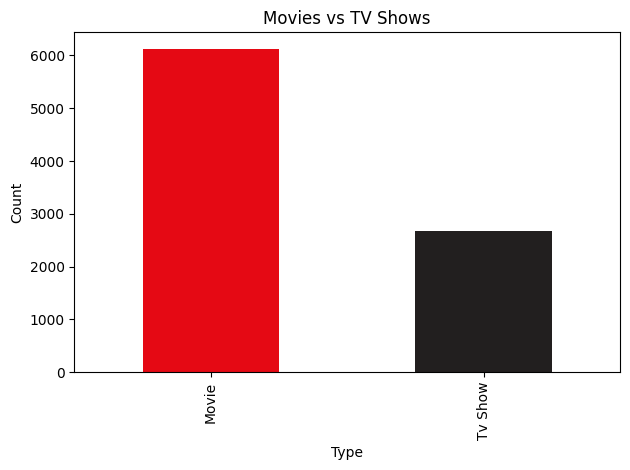

In [43]:
# Content Type Distribution
df['type'].value_counts().plot(kind='bar', color=['#e50914', '#221f1f'])
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

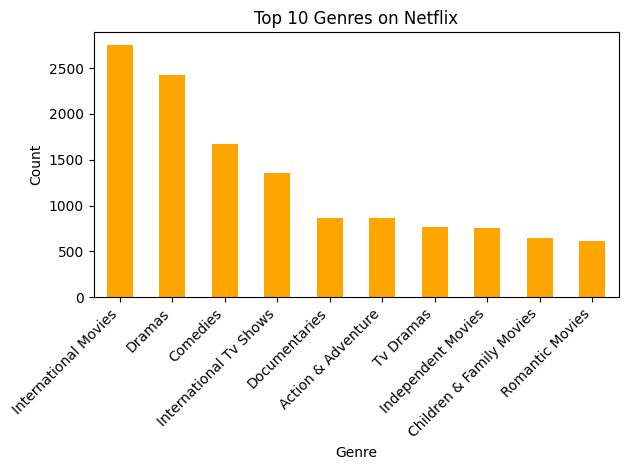

In [44]:
# Genre Distribution
df_exploded = df.explode('genres')
df_exploded['genres'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

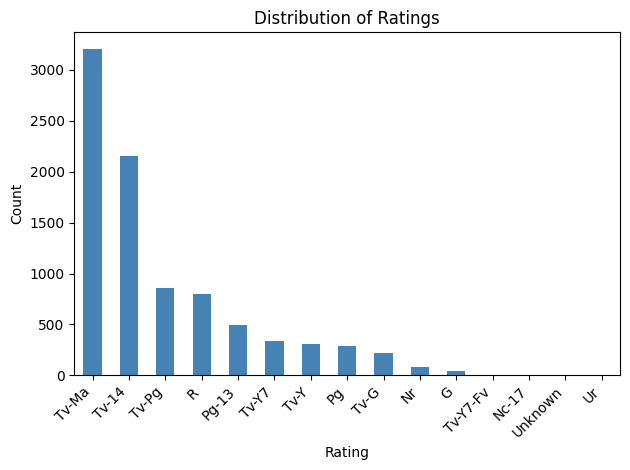

In [45]:
# Rating Distribution
df['rating'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

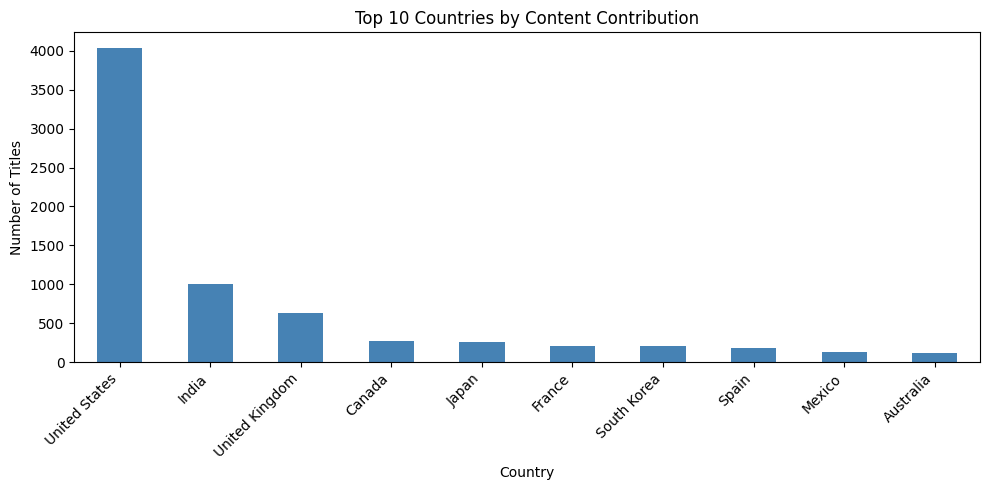

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# COUNTRY LEVEL CONTENT CONTRIBUTION

df['primary_country'] = df['country'].apply(lambda x: x.split(',')[0].strip())

df['primary_country'].value_counts().head(10).plot(kind='bar', color='steelblue', figsize=(10, 5))
plt.title("Top 10 Countries by Content Contribution")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



plt.show()

Week- 5


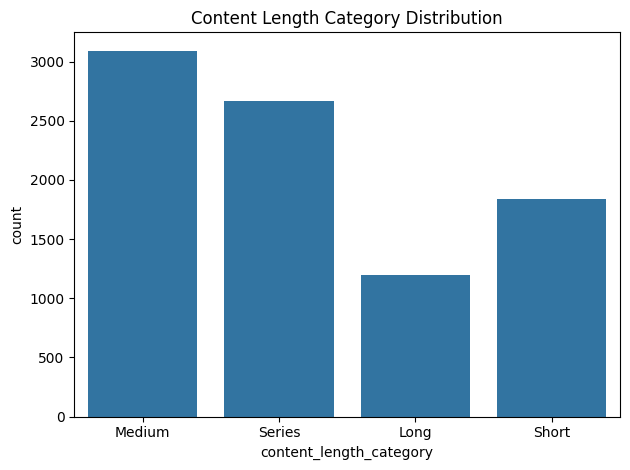

In [47]:
# CONTENT LENGTH CATEGORY

df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

def categorize_length(row):
    if row['type'] == 'Movie':
        if row['duration_int'] < 90:
            return 'Short'
        elif row['duration_int'] < 120:
            return 'Medium'
        else:
            return 'Long'
    return 'Series'

df['content_length_category'] = df.apply(categorize_length, axis=1)

sns.countplot(data=df, x='content_length_category')
plt.title("Content Length Category Distribution")
plt.tight_layout()
plt.show()



In [48]:

df['year_added'] = df['date_added'].dt.year

def determine_originality(row):

    if pd.isna(row['year_added']):
        return 'Unknown'
    if row['release_year'].year == row['year_added']:
        return 'Original'
    else:
        return 'Licensed'

df['original_vs_licensed'] = df.apply(determine_originality, axis=1)

print(df['original_vs_licensed'].value_counts())


original_vs_licensed
Licensed    5556
Original    3241
Name: count, dtype: int64


In [49]:
df.head(12)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,primary_country,year_added,month_added,duration_val,duration_unit,movie_mins,tv_seasons,duration_int,content_length_category,original_vs_licensed
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020-01-01,Pg-13,90 min,...,United States,2021,September,90.0,min,90.0,NaN,90.0,Medium,Licensed
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021-01-01,Tv-Ma,2 Seasons,...,South Africa,2021,September,2.0,Seasons,NaN,2.0,2.0,Series,Original
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021-01-01,Tv-Ma,1 Season,...,United States,2021,September,1.0,Season,NaN,1.0,1.0,Series,Original
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021-09-24,2021-01-01,Tv-Ma,1 Season,...,United States,2021,September,1.0,Season,NaN,1.0,1.0,Series,Original
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021-01-01,Tv-Ma,2 Seasons,...,India,2021,September,2.0,Seasons,NaN,2.0,2.0,Series,Original
5,s6,Tv Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,2021-09-24,2021-01-01,Tv-Ma,1 Season,...,United States,2021,September,1.0,Season,NaN,1.0,1.0,Series,Original
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021-01-01,Pg,91 min,...,United States,2021,September,91.0,min,91.0,NaN,91.0,Medium,Original
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993-01-01,Tv-Ma,125 min,...,United States,2021,September,125.0,min,125.0,NaN,125.0,Long,Licensed
8,s9,Tv Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021-01-01,Tv-14,9 Seasons,...,United Kingdom,2021,September,9.0,Seasons,NaN,9.0,9.0,Series,Original
9,s10,Movie,The Starling,Theodore Melfi,"Melissa Mccarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021-01-01,Pg-13,104 min,...,United States,2021,September,104.0,min,104.0,NaN,104.0,Medium,Original


Data prepared for ML!
Total genre columns created: 42
   rating_encoded  country_encoded  duration_int
0               4               80          90.0
1               2               67           2.0
2               2               80           1.0
3               2               80           1.0
4               2               30           2.0


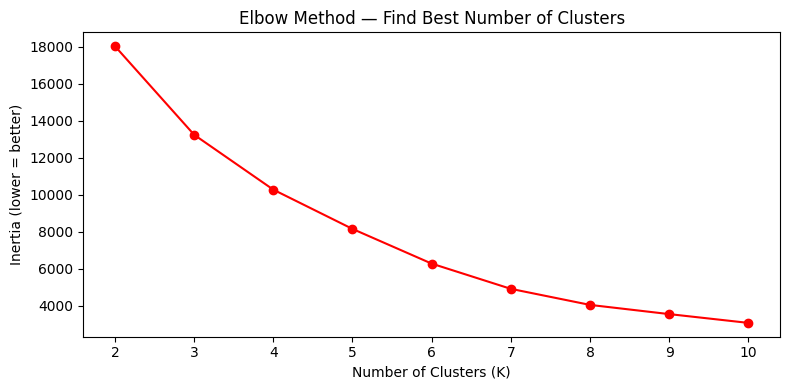

Cluster sizes (how many titles in each group):
cluster
0    2691
3    2341
2    1951
1    1814
Name: count, dtype: int64


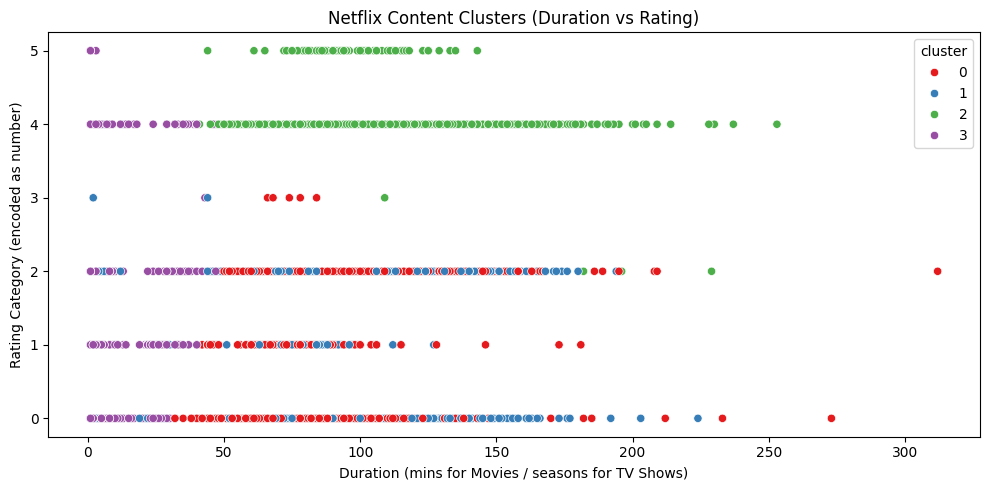

In [50]:

# CLUSTERING

from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# CONVERT TEXT COLUMNS TO NUMBERS
le = LabelEncoder()

df['rating_encoded'] = le.fit_transform(df['rating_category'].fillna('Other'))
df['country_encoded'] = le.fit_transform(df['primary_country'].fillna('Unknown'))


mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(
    mlb.fit_transform(df['genres']),
    columns=mlb.classes_,
    index=df.index
)

print("Data prepared for ML!")
print(f"Total genre columns created: {len(mlb.classes_)}")
print(df[['rating_encoded', 'country_encoded', 'duration_int']].head())

#  PREPARE DATA FOR CLUSTERING

cluster_df = df[['duration_int', 'rating_encoded', 'country_encoded']].dropna()

# SCALE THE FEATURES

scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_df)


inertia = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), inertia, marker='o', color='red')
plt.title('Elbow Method — Find Best Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (lower = better)')
plt.tight_layout()
plt.show()

#  APPLY KMEANS WITH BEST K

K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)

cluster_df['cluster'] = km.fit_predict(scaled)

# Copy cluster labels back to the main dataframe
df.loc[cluster_df.index, 'cluster'] = cluster_df['cluster']

print("Cluster sizes (how many titles in each group):")
print(cluster_df['cluster'].value_counts())

#  VISUALIZE THE CLUSTERS
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=cluster_df,
    x='duration_int',
    y='rating_encoded',
    hue='cluster',
    palette='Set1'
)
plt.title('Netflix Content Clusters (Duration vs Rating)')
plt.xlabel('Duration (mins for Movies / seasons for TV Shows)')
plt.ylabel('Rating Category (encoded as number)')
plt.tight_layout()
plt.show()

In [51]:
#  Classification (Movie vs TV Show Prediction)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

features = ['duration_int', 'rating_encoded', 'country_encoded']
X = df[features].dropna()
y = df.loc[X.index, 'type']

y_encoded = LabelEncoder().fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Movie', 'TV Show']))

Classification Report:
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1229
     TV Show       0.99      1.00      1.00       531

    accuracy                           1.00      1760
   macro avg       1.00      1.00      1.00      1760
weighted avg       1.00      1.00      1.00      1760



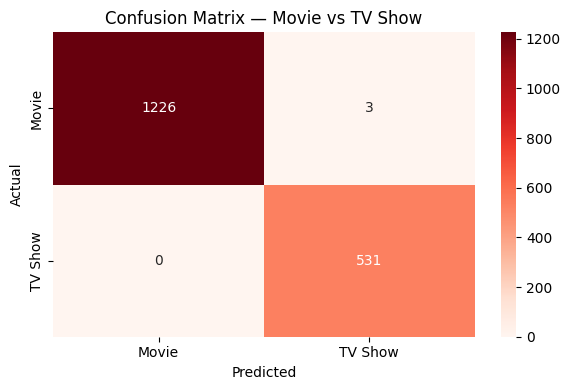

In [52]:
# Confusion matrix shows:  (How many did it get right/wrong)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Movie', 'TV Show'],
            yticklabels=['Movie', 'TV Show'])
plt.title('Confusion Matrix — Movie vs TV Show')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

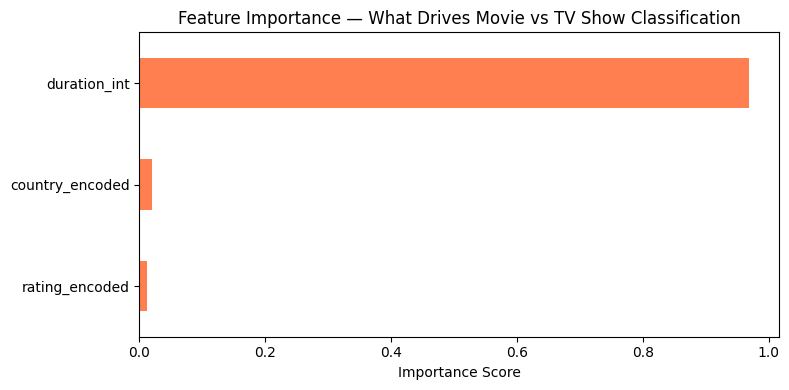

duration_int       0.968562
country_encoded    0.020003
rating_encoded     0.011435
dtype: float64


In [53]:
# Feature importance tells us:

importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='coral', figsize=(8, 4))
plt.title('Feature Importance — What Drives Movie vs TV Show Classification')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))

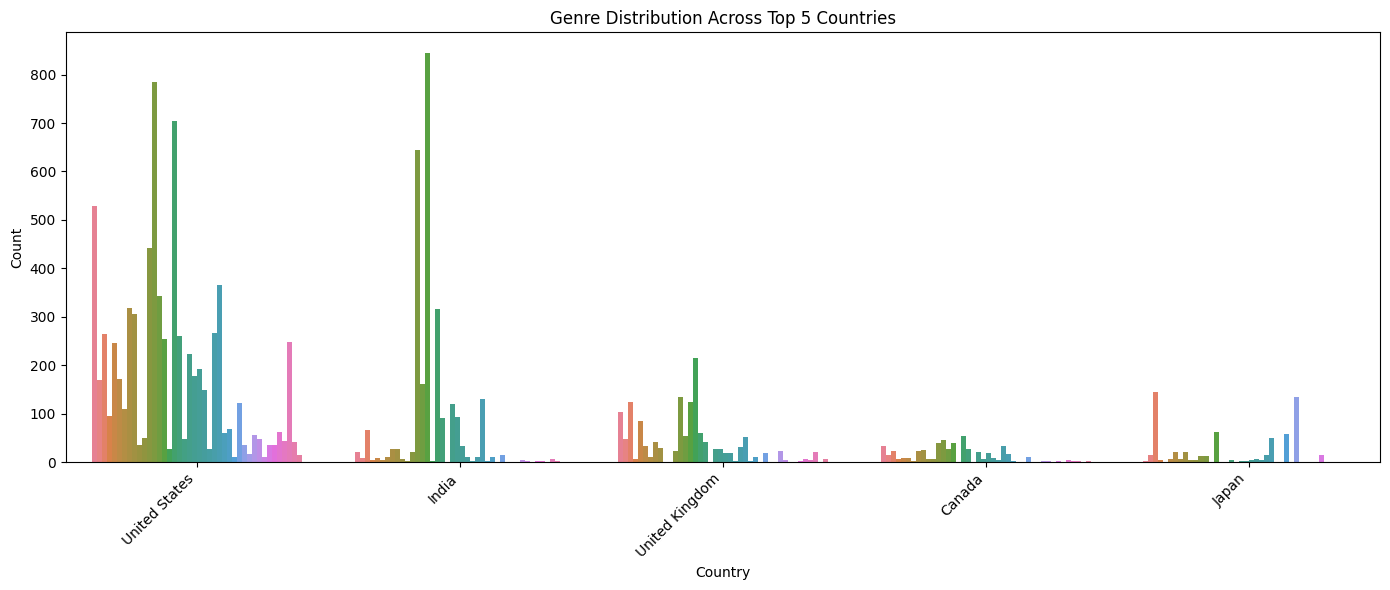

Top genre per country:
                                 genres  count
primary_country                               
Canada                         Comedies     54
India              International Movies    845
Japan            International Tv Shows    144
United Kingdom         British Tv Shows    215
United States                    Dramas    784


In [54]:
# Which genres dominate in each top country?
top_5_countries = df['primary_country'].value_counts().head(5).index.tolist()

country_genre_df = df[df['primary_country'].isin(top_5_countries)].explode('genres')

plt.figure(figsize=(14, 6))
sns.countplot(
    data=country_genre_df,
    x='primary_country',
    hue='genres',
    order=top_5_countries,
    legend=False
)
plt.title('Genre Distribution Across Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Simpler version — top genre per country
top_genre_per_country = (
    country_genre_df.groupby(['primary_country', 'genres'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .groupby('primary_country')
    .first()
)
print("Top genre per country:")
print(top_genre_per_country)